In [16]:
import ImtaTURB as imta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [17]:
file_U = "Datos/OpenFOAM/20_cm/U"
file_p = "Datos/OpenFOAM/20_cm/p.csv"

In [18]:
df = pd.read_csv(file_p, sep=r',')
print("Probes cargadas:", df.columns)
print("(filas, columnas)", df.shape)
# Creando copia del DataFrame para evitar modificar el original
pk = df.copy()
# Se ignoran el primer segundos de dato (Arranque del modelo LES)
pk = pk.iloc[5000:-1, :]

Probes cargadas: Index(['0', 'Probe_0', 'Probe_1', 'Probe_2', 'Probe_3', 'Probe_4', 'Probe_5',
       'Probe_6', 'Probe_7', 'Probe_8',
       ...
       'Probe_158', 'Probe_159', 'Probe_160', 'Probe_161', 'Probe_162',
       'Probe_163', 'Probe_164', 'Probe_165', 'Probe_166', 'Probe_167'],
      dtype='object', length=169)
(filas, columnas) (20001, 169)


In [19]:
# Conversión de pk a p_cinematica
rho = 1000.00 # Densidad del fluido (kg/m^3)
p_est = pk * rho # Presión estática (Pa)
p_est_med = p_est.mean()  # Media de la presión estática

print(p_est_med)

0            124995.000000
Probe_0           2.818816
Probe_1           2.817734
Probe_2           2.816843
Probe_3           8.052115
                 ...      
Probe_163        -9.040293
Probe_164        -9.040293
Probe_165        -9.455714
Probe_166        -9.455714
Probe_167        -9.050810
Length: 169, dtype: float64


In [20]:
print(p_est_med.loc['Probe_25'])

-13.4138143069


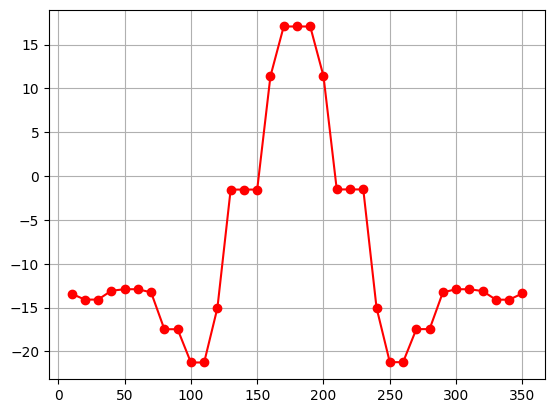

In [28]:
presiones = [ p_est_med.loc['Probe_25'],
              p_est_med.loc['Probe_26'],
              p_est_med.loc['Probe_27'],
              p_est_med.loc['Probe_28'],
              p_est_med.loc['Probe_29'],
              p_est_med.loc['Probe_30'],
              p_est_med.loc['Probe_31'],
              p_est_med.loc['Probe_32'],
              p_est_med.loc['Probe_33'],
              p_est_med.loc['Probe_34'],
              p_est_med.loc['Probe_35'],
              p_est_med.loc['Probe_36'],
              p_est_med.loc['Probe_37'],
              p_est_med.loc['Probe_38'],
              p_est_med.loc['Probe_39'],
              p_est_med.loc['Probe_40'],
              p_est_med.loc['Probe_41'],
              p_est_med.loc['Probe_42'],
              p_est_med.loc['Probe_43'],
              p_est_med.loc['Probe_44'],
              p_est_med.loc['Probe_45'],
              p_est_med.loc['Probe_46'],
              p_est_med.loc['Probe_47'],
              p_est_med.loc['Probe_48'],
              p_est_med.loc['Probe_49'],
              p_est_med.loc['Probe_50'],
              p_est_med.loc['Probe_51'],
              p_est_med.loc['Probe_52'],
              p_est_med.loc['Probe_53'],
              p_est_med.loc['Probe_54'],
              p_est_med.loc['Probe_55'],
              p_est_med.loc['Probe_56'],
              p_est_med.loc['Probe_57'],
              p_est_med.loc['Probe_58'],
              p_est_med.loc['Probe_59'] ]

# Generar ángulos de 0 a 360 cada 10 grados
angulos_grad = np.arange(10, 360, 10)

plt.plot(angulos_grad, presiones, 'ro-')
plt.grid(True)
plt.show()


# **Regímenes de flujo alrededor de un cilindro circular liso**
Las cantidades adimensionales que describen el flujo alrededor de un cilindro circular liso dependen del número de Reynolds del cilindro:$$Re = \frac{DU}{\nu} \quad (1.1)$$en donde $D$ es el diámetro del cilindro, $U$ es la velocidad del flujo y $\nu$ es la viscosidad cinemática.


In [ ]:
# Aplicación de fórmulas según B. Mutlu [2006]
# Hydrodynamics Around Cylindrical Structures (1.1)
D = 0.05 # Diametro de cilindro en metros
U = 0.194 # Velocidad en m/s
nu = 1e-6 # Viscocidad en m^2/s
Re = (D*U)/nu
print("(1.1) Re =", Re)
print("Subcrítico. Esteña completamente turbulenta. Separacion de la capa límite laminar.")

(1.1) Re = 9700.0
Subcrítico. Esteña completamente turbulenta. Separacion de la capa límite laminar.


El flujo experimenta cambios tremendos a medida que el número de Reynolds aumenta desde cero. Los regímenes de flujo experimentados con el aumento del $Re$ se resumen en la Fig. 1.1.
<img src="./Datos/Imagenes/Figure_1.1.png" style="height: 50em; vertical-align: middle;">

La Fig. 1.2, por otro lado, proporciona el esquema de definición respecto a las dos regiones de flujo diferentes referidas en la Fig. 1.1, específicamente la estela y la capa límite. <br>
<img src="./Datos/Imagenes/Figure_1.2.png" style="height: 15em; vertical-align: middle;"> <br>

Mientras que la estela se extiende sobre una distancia que es comparable con el diámetro del cilindro, $D$, la capa límite se extiende sobre un espesor muy pequeño, $\delta$, el cual es normalmente pequeño en comparación con $D$. El espesor de la capa límite, en el caso de la capa límite laminar, por ejemplo, (Schlichting, 1979)
$$\frac{\delta}{D} = O\left(\frac{1}{\sqrt{Re}}\right)$$
y se observa que $\delta/D \ll 1$ para $Re$ mayores que el orden de $O(100)$, aproximadamente.

# 1.2 Desprendimiento de vórtices
La característica más importante de los regímenes de flujo descritos en la sección anterior es el fenómeno de desprendimiento de vórtices, el cual es común a todos los regímenes de flujo para $Re > 40$ (Fig. 1.1). Para estos valores de $Re$, la capa límite sobre la superficie del cilindro se separará debido al gradiente de presión adverso impuesto por la geometría divergente del entorno del flujo en la parte posterior del cilindro. Como resultado de esto, se forma una capa de cizalladura (o capa de corte), tal como se esquematiza en la Fig. 1.5.<br>

Como se observa en la Fig. 1.6, la capa límite formada a lo largo del cilindro contiene una cantidad significativa de vorticidad. Esta vorticidad se transfiere a la capa de cizalladura formada aguas abajo del punto de separación y provoca que dicha capa se enrolle formando un vórtice con un signo idéntico al de la vorticidad entrante (Vórtice A en la Fig. 1.5).Del mismo modo, un vórtice que rota en la dirección opuesta se forma en el otro lado del cilindro (Vórtice B).

In [22]:
#U_probes, tiempo, coords, frecuencia = imta.cargar_U_OpenFOAM(file_U)